In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    root="/datasets/apollo2506/eurosat-dataset/EuroSAT",
    transform=transform
)

In [ ]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
model = resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("model/best_model.pth"))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [22]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [24]:
cm = confusion_matrix(all_labels, all_preds)

Confusion Matrix Visualisation

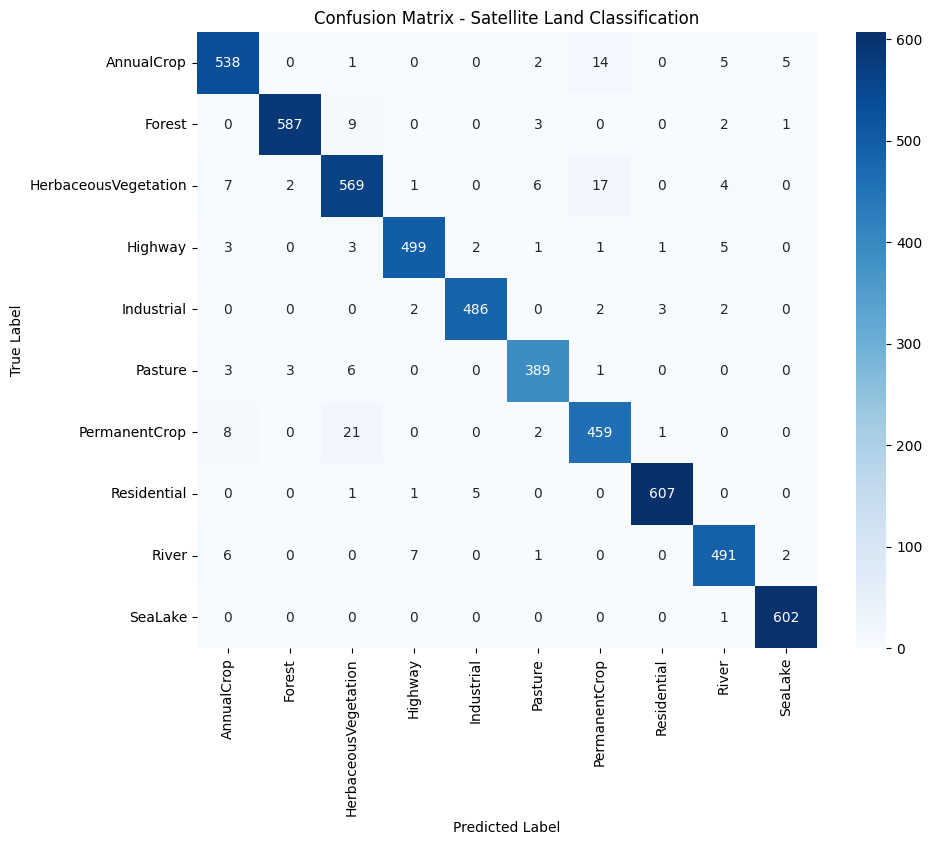

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm, 
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels = dataset.classes,
    yticklabels = dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Satellite Land Classification")

plt.show()

Classification report

In [28]:
print(classification_report(
    all_labels, all_preds,
    target_names = dataset.classes
))

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.95      0.95       565
              Forest       0.99      0.98      0.98       602
HerbaceousVegetation       0.93      0.94      0.94       606
             Highway       0.98      0.97      0.97       515
          Industrial       0.99      0.98      0.98       495
             Pasture       0.96      0.97      0.97       402
       PermanentCrop       0.93      0.93      0.93       491
         Residential       0.99      0.99      0.99       614
               River       0.96      0.97      0.97       507
             SeaLake       0.99      1.00      0.99       603

            accuracy                           0.97      5400
           macro avg       0.97      0.97      0.97      5400
        weighted avg       0.97      0.97      0.97      5400

